In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# Tarea B — Atención escalada y codificación posicional (Vaswani et al., 2017)

## Tarea B — Atención escalada y codificación posicional

Notebook de la práctica **MMIA 6013 · Taller 03 v2** (solver multiagente). Es un único notebook ejecutado de principio a fin sin errores: **todas las cifras se calculan en las celdas de código** y el texto solo reporta sus salidas; ninguna cifra se escribe a mano.

El Transformer de *Attention Is All You Need* calcula la atención escalada punto a punto

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

y suma a cada token una codificación posicional sinusoidal. Este notebook implementa ambos componentes en NumPy y experimenta con ellos:

- **Parte 1** — atención escalada con softmax numéricamente estable, para las matrices del enunciado.
- **Parte 2** — experimento controlado sobre el efecto de escalar (o no) por √d_k.
- **Parte 3** — codificación posicional sinusoidal y atención de una posición sobre todas las demás.
- **Parte 4** — discusión conceptual: qué resuelve la división por √d_k y su relación con el paper.

Datos del enunciado (dos consultas, tres claves de dimensión 4 y sus valores):

**Q (2 × 4)**

| | col 1 | col 2 | col 3 | col 4 |
|---|---:|---:|---:|---:|
| q₁ | 1.0 | 0.0 | 1.0 | 0.5 |
| q₂ | 0.0 | 2.0 | 0.0 | 1.0 |

**K (3 × 4)**

| | col 1 | col 2 | col 3 | col 4 |
|---|---:|---:|---:|---:|
| k₁ | 1.0 | 1.0 | 0.0 | 0.0 |
| k₂ | 0.0 | 1.0 | 1.0 | 0.5 |
| k₃ | 1.0 | 0.0 | 1.0 | 1.0 |

**V (3 × 2)**

| | col 1 | col 2 |
|---|---:|---:|
| v₁ | 1.0 | 0.0 |
| v₂ | 0.0 | 1.0 |
| v₃ | 2.0 | 2.0 |

## Parte 1 — Atención escalada

In [2]:
# Subtarea T1: código aprobado (se ejecuta en trabajo/T1/)
os.chdir(RAIZ / 'trabajo' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Parte 1 — Atención escalada en NumPy
Implementa Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V con softmax
numéricamente estable (restando el máximo de cada fila), usando las matrices
del enunciado. Guarda los resultados en resultados.json y los imprime con
cuatro decimales.
"""

import json
import numpy as np
from scipy.special import softmax as scipy_softmax  # solo para verificación


# ----------------------------------------------------------------------
# 1. Matrices del enunciado
# ----------------------------------------------------------------------
Q = np.array([[1.0, 0.0, 1.0, 0.5],
              [0.0, 2.0, 0.0, 1.0]])          # (2, 4)  -> 2 consultas, d_k = 4

K = np.array([[1.0, 1.0, 0.0, 0.0],
              [0.0, 1.0, 1.0, 0.5],
              [1.0, 0.0, 1.0, 1.0]])          # (3, 4)  -> 3 claves

V = np.array([[1.0, 0.0],
              [0.0, 1.0],
              [2.0, 2.0]])                    # (3, 2)  -> 3 valores, d_v = 2

d_k = Q.shape[1]          # dimensión de las claves/consultas = 4
sqrt_dk = float(np.sqrt(d_k))


# ----------------------------------------------------------------------
# 2. Softmax numéricamente estable (resta el máximo de cada fila)
# ----------------------------------------------------------------------
def softmax_estable(x, axis=-1):
    """Softmax estable: exp(x - max_fila) / sum(exp(x - max_fila))."""
    z = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)


# ----------------------------------------------------------------------
# 3. Atención escalada
# ----------------------------------------------------------------------
scores = (Q @ K.T) / sqrt_dk          # (2, 3)  puntuaciones QK^T / sqrt(d_k)
pesos = softmax_estable(scores, axis=1)   # (2, 3)  pesos de atención
salida = pesos @ V                        # (2, 2)  salida de la atención

# Verificación cruzada con scipy (misma definición de softmax)
pesos_scipy = scipy_softmax(scores, axis=1)
max_diff_verif = float(np.max(np.abs(pesos - pesos_scipy)))


# ----------------------------------------------------------------------
# 4. Guardar todas las cifras en resultados.json (precisión completa)
# ----------------------------------------------------------------------
resultados = {
    "Q_2x4": Q.tolist(),
    "K_3x4": K.tolist(),
    "V_3x2": V.tolist(),
    "d_k": int(d_k),
    "sqrt_d_k": sqrt_dk,
    "scores_escalados_2x3": scores.tolist(),
    "pesos_atencion_2x3": pesos.tolist(),                 # precisión completa
    "salida_atencion_2x2": salida.tolist(),               # precisión completa
    "pesos_atencion_2x3_4decimales": np.round(pesos, 4).tolist(),
    "salida_atencion_2x2_4decimales": np.round(salida, 4).tolist(),
    "suma_filas_pesos": pesos.sum(axis=1).tolist(),
    "verificacion_max_abs_diff_vs_scipy_softmax": max_diff_verif,
}

with open("resultados.json", "w") as f:
    json.dump(resultados, f, indent=2)


# ----------------------------------------------------------------------
# 5. Impresión de las cifras principales (con cuatro decimales)
# ----------------------------------------------------------------------
np.set_printoptions(precision=4, suppress=True)

print("=" * 62)
print("Atención escalada:  Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V")
print("=" * 62)
print(f"d_k = {d_k}   ->   sqrt(d_k) = {sqrt_dk:.4f}")
print("\nQ (2x4):\n", Q)
print("\nK (3x4):\n", K)
print("\nV (3x2):\n", V)

print("\nPuntuaciones escaladas QK^T/sqrt(d_k) (2x3):\n", scores)

print("\nPesos de atención softmax(QK^T/sqrt(d_k)) (2x3), 4 decimales:")
print(np.round(pesos, 4))

print("\nSalida Attention(Q,K,V) (2x2), 4 decimales:")
print(np.round(salida, 4))

print("\nSuma de cada fila de los pesos (debe ser 1.0):", np.round(pesos.sum(axis=1), 6))
print(f"Verificación vs scipy.special.softmax (max |diff|): {max_diff_verif:.2e}")
print("\nResultados guardados en 'resultados.json'")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T1')

Atención escalada:  Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
d_k = 4   ->   sqrt(d_k) = 2.0000

Q (2x4):
 [[1.  0.  1.  0.5]
 [0.  2.  0.  1. ]]

K (3x4):
 [[1.  1.  0.  0. ]
 [0.  1.  1.  0.5]
 [1.  0.  1.  1. ]]

V (3x2):
 [[1. 0.]
 [0. 1.]
 [2. 2.]]

Puntuaciones escaladas QK^T/sqrt(d_k) (2x3):
 [[0.5   0.625 1.25 ]
 [1.    1.25  0.5  ]]

Pesos de atención softmax(QK^T/sqrt(d_k)) (2x3), 4 decimales:
[[0.2353 0.2666 0.4981]
 [0.346  0.4442 0.2098]]

Salida Attention(Q,K,V) (2x2), 4 decimales:
[[1.2315 1.2628]
 [0.7656 0.8639]]

Suma de cada fila de los pesos (debe ser 1.0): [1. 1.]
Verificación vs scipy.special.softmax (max |diff|): 0.00e+00

Resultados guardados en 'resultados.json'


La celda anterior implementa en NumPy la atención escalada $\mathrm{softmax}(QK^{\top}/\sqrt{d_k})\,V$ con un **softmax numéricamente estable**: a cada fila de puntajes se le resta su máximo antes de exponenciar, lo que evita desbordes sin alterar el resultado. Con $d_k = 4$, el factor de escala es $\sqrt{d_k} = 2.0$.

**Puntuaciones escaladas** $QK^{\top}/\sqrt{d_k}$ **(2 × 3):**

| | k₁ | k₂ | k₃ |
|---|---:|---:|---:|
| q₁ | 0.5 | 0.625 | 1.25 |
| q₂ | 1.0 | 1.25 | 0.5 |

**Pesos de atención** $\mathrm{softmax}(QK^{\top}/\sqrt{d_k})$ **(2 × 3), cuatro decimales:**

| | k₁ | k₂ | k₃ |
|---|---:|---:|---:|
| q₁ | 0.2353 | 0.2666 | 0.4981 |
| q₂ | 0.3460 | 0.4442 | 0.2098 |

**Salida** $\mathrm{Attention}(Q,K,V)$ **(2 × 2), cuatro decimales:**

| | dim 1 | dim 2 |
|---|---:|---:|
| q₁ | 1.2315 | 1.2628 |
| q₂ | 0.7656 | 0.8639 |

Verificaciones de la celda: la suma de cada fila de los pesos es 1.0 (dentro del redondeo de punto flotante) y la comparación con `scipy.special.softmax` arroja una diferencia máxima absoluta de **0.0**.

Lectura: la consulta q₁ concentra el mayor peso en la clave k₃ (0.4981) y la consulta q₂ en la clave k₂ (0.4442); cada fila de la salida es la mezcla de las filas de V ponderada por esos pesos.

## Parte 2 — Por qué se divide por √d_k

In [3]:
# Subtarea T2: código aprobado (se ejecuta en trabajo/T2/)
os.chdir(RAIZ / 'trabajo' / 'T2')

import json
import numpy as np


def softmax_estable(x):
    """Softmax numéricamente estable: resta el máximo antes de exponenciar."""
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


def entropia_bits(p):
    """Entropía de Shannon en bits; términos con p=0 aportan 0."""
    p = np.asarray(p, dtype=float)
    mascara = p > 0
    return float(-np.sum(p[mascara] * np.log2(p[mascara])))


# Generador único, creado una sola vez (semilla 0)
rng = np.random.default_rng(0)

d_k_valores = [4, 64, 512]

peso_maximo_sin_escalar = []
entropia_bits_sin_escalar = []
peso_maximo_escalado = []
entropia_bits_escalado = []
tabla_filas = []

for d_k in d_k_valores:
    # Orden estricto de consumo del generador: primero q, después K
    q = rng.standard_normal(d_k)
    K = rng.standard_normal((10, d_k))

    puntajes = K @ q  # forma (10,)

    # Distribuciones de pesos de atención
    pesos_sin = softmax_estable(puntajes)                 # sin escalar
    pesos_esc = softmax_estable(puntajes / np.sqrt(d_k))  # escalado por sqrt(d_k)

    pm_sin = float(np.max(pesos_sin))
    eb_sin = entropia_bits(pesos_sin)
    pm_esc = float(np.max(pesos_esc))
    eb_esc = entropia_bits(pesos_esc)

    peso_maximo_sin_escalar.append(pm_sin)
    entropia_bits_sin_escalar.append(eb_sin)
    peso_maximo_escalado.append(pm_esc)
    entropia_bits_escalado.append(eb_esc)

    tabla_filas.append({
        "d_k": int(d_k),
        "peso_maximo_sin_escalar": pm_sin,
        "entropia_bits_sin_escalar": eb_sin,
        "peso_maximo_escalado": pm_esc,
        "entropia_bits_escalado": eb_esc,
    })

# Guardar todas las cifras con precisión completa en resultados.json
resultados = {
    "d_k_valores": [int(d) for d in d_k_valores],
    "peso_maximo_sin_escalar": peso_maximo_sin_escalar,
    "entropia_bits_sin_escalar": entropia_bits_sin_escalar,
    "peso_maximo_escalado": peso_maximo_escalado,
    "entropia_bits_escalado": entropia_bits_escalado,
    "tabla": tabla_filas,
}

with open("resultados.json", "w") as f:
    json.dump(resultados, f, indent=2)

# Tabla con cuatro decimales
encabezado = (
    f"{'d_k':>6} | {'peso_max_sin':>14} | {'entropia_bits_sin':>18} | "
    f"{'peso_max_esc':>14} | {'entropia_bits_esc':>18}"
)
print(encabezado)
print("-" * len(encabezado))
for fila in tabla_filas:
    print(
        f"{fila['d_k']:>6} | "
        f"{fila['peso_maximo_sin_escalar']:>14.4f} | "
        f"{fila['entropia_bits_sin_escalar']:>18.4f} | "
        f"{fila['peso_maximo_escalado']:>14.4f} | "
        f"{fila['entropia_bits_escalado']:>18.4f}"
    )

print()
print("Cifras guardadas en resultados.json (precisión completa):")
print("  peso_maximo_sin_escalar   =", peso_maximo_sin_escalar)
print("  entropia_bits_sin_escalar =", entropia_bits_sin_escalar)
print("  peso_maximo_escalado      =", peso_maximo_escalado)
print("  entropia_bits_escalado    =", entropia_bits_escalado)

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T2')

   d_k |   peso_max_sin |  entropia_bits_sin |   peso_max_esc |  entropia_bits_esc
----------------------------------------------------------------------------------
     4 |         0.2049 |             3.0792 |         0.1497 |             3.2542
    64 |         0.9511 |             0.3537 |         0.2480 |             2.9802
   512 |         0.7503 |             0.8114 |         0.1945 |             3.0363

Cifras guardadas en resultados.json (precisión completa):
  peso_maximo_sin_escalar   = [0.20485252483535019, 0.9510548134515442, 0.7502787070295298]
  entropia_bits_sin_escalar = [3.079238113192825, 0.3536586163885896, 0.8114162792180564]
  peso_maximo_escalado      = [0.149659127182818, 0.2480301668328573, 0.19454829106456933]
  entropia_bits_escalado    = [3.254238320333844, 2.9801627906557933, 3.0363260510347274]


Protocolo de la celda: se crea **una sola vez** el generador `rng = np.random.default_rng(0)`. Para $d_k = 4, 64, 512$, **en ese orden**, se toma $q = \texttt{rng.standard\_normal}(d_k)$ y después $K = \texttt{rng.standard\_normal}((10, d_k))$; se calculan los pesos softmax de los puntajes $K q$ **sin escalar** y **escalados por √d_k**, y se reporta el peso máximo y la entropía en bits de cada distribución.

| d_k | Peso máx. sin escalar | Entropía (bits) sin escalar | Peso máx. escalado | Entropía (bits) escalado |
|---:|---:|---:|---:|---:|
| 4 | 0.2049 | 3.0792 | 0.1497 | 3.2542 |
| 64 | 0.9511 | 0.3537 | 0.2480 | 2.9802 |
| 512 | 0.7503 | 0.8114 | 0.1945 | 3.0363 |

Comentario breve: con $d_k$ grande y **sin escalar**, la distribución colapsa hacia un solo valor (peso máximo 0.9511 y entropía 0.3537 bits para $d_k=64$); **escalando**, la entropía se recupera (2.9802 y 3.0363 bits para $d_k=64$ y $512$). Con $d_k=4$ la diferencia es pequeña. La discusión completa se desarrolla en la Parte 4.

## Parte 3 — Codificación posicional

Verificación de la función de atención vs T1:
  max|Δ pesos|  = 0.0
  max|Δ salida| = 0.0

Codificación posicional (d_model=16, pos=0..49):
  PE[10, 0] = -0.5440211108893698
  PE[10, 1] = -0.8390715290764524
  PE[25, 6] = 0.7107539373458333

Atención con PE[10] como consulta (d_k = 16):
  Posición con mayor peso: 10
  Peso mayor: 0.04181333902522971
  Suma de los 50 pesos: 1.0
  Top-5 posiciones por peso:
    pos 10 -> peso 0.041813
    pos  9 -> peso 0.036764
    pos 11 -> peso 0.036764
    pos  4 -> peso 0.028344
    pos 16 -> peso 0.028344



Guardado: resultados.json, mapa_calor_pe.png, pesos_atencion_pe.png


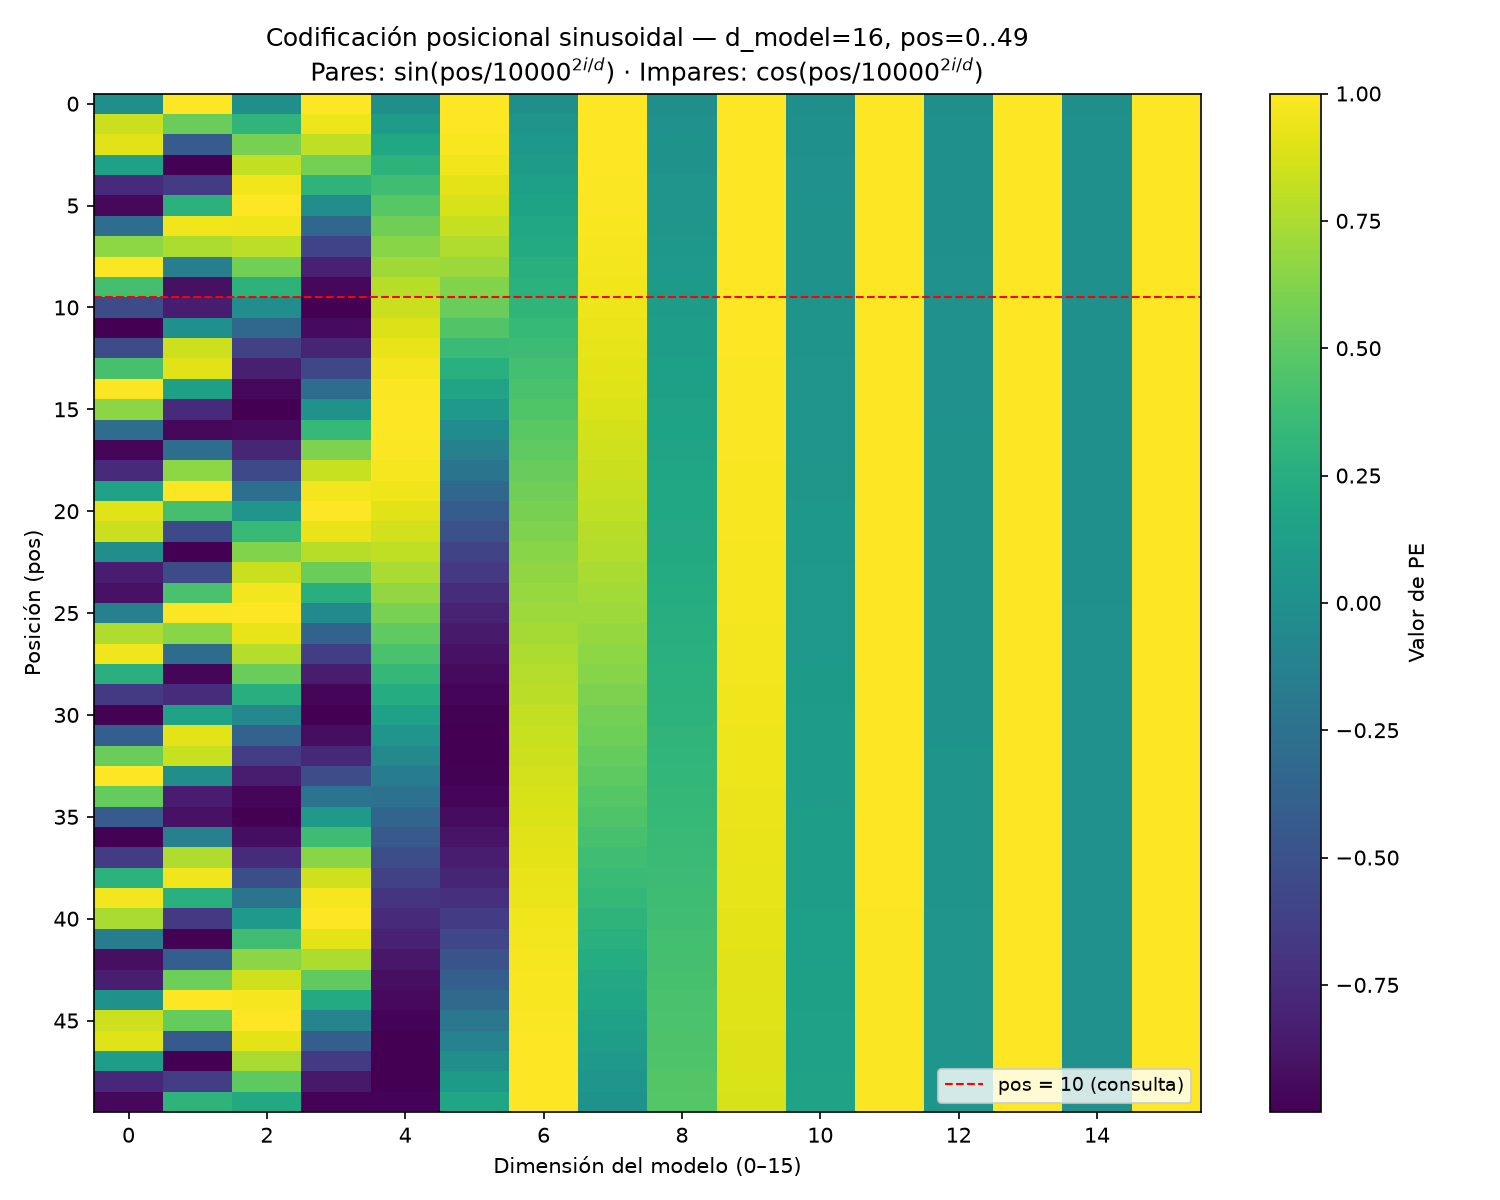

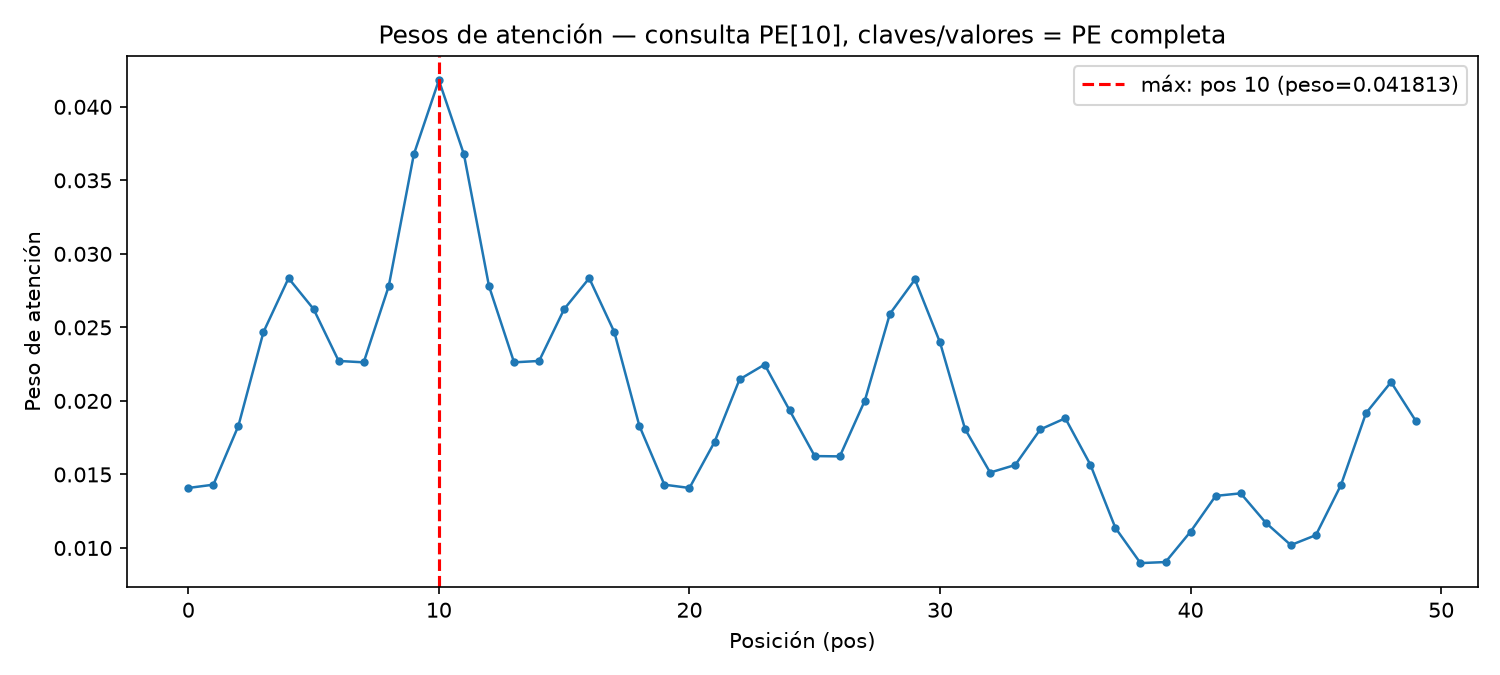

In [4]:
# Subtarea T3: código aprobado (se ejecuta en trabajo/T3/)
os.chdir(RAIZ / 'trabajo' / 'T3')

# -*- coding: utf-8 -*-
"""
SUBTAREA T3 — Parte 3 — Codificación posicional sinusoidal (Vaswani et al., 2017)

1) Calcula PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
          PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
   con d_model = 16 y pos = 0..49.
2) Reporta PE[10,0], PE[10,1], PE[25,6].
3) Dibuja la matriz PE completa (50x16) como mapa de calor -> mapa_calor_pe.png.
4) Reutiliza la función de atención escalada de la Parte 1 (softmax numéricamente
   estable, resta el máximo por fila) con PE[10] como consulta y la matriz PE
   completa (50x16) como claves y valores; reporta la posición con mayor peso.
"""

import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# Función de atención de la Parte 1 (softmax numéricamente estable)
# ----------------------------------------------------------------------
def softmax_estable(x, axis=-1):
    """Softmax estable: resta el máximo a lo largo del eje antes de exponenciar."""
    x = np.asarray(x, dtype=float)
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)


def atencion_escalada(Q, K, V):
    """Attention(Q,K,V) = softmax(Q K^T / sqrt(d_k)) V  (Parte 1)."""
    d_k = K.shape[-1]
    scores = (Q @ K.T) / np.sqrt(d_k)
    pesos = softmax_estable(scores, axis=-1)
    salida = pesos @ V
    return scores, pesos, salida


# ----------------------------------------------------------------------
# Cargar resultados de la Parte 1 (T1) y verificar la función reutilizada
# ----------------------------------------------------------------------
with open("entradas/T1.json", "r", encoding="utf-8") as f:
    t1 = json.load(f)

Q1 = np.array(t1["Q_2x4"], dtype=float)
K1 = np.array(t1["K_3x4"], dtype=float)
V1 = np.array(t1["V_3x2"], dtype=float)
_, pesos1, salida1 = atencion_escalada(Q1, K1, V1)
diff_pesos = float(np.max(np.abs(pesos1 - np.array(t1["pesos_atencion_2x3"], dtype=float))))
diff_salida = float(np.max(np.abs(salida1 - np.array(t1["salida_atencion_2x2"], dtype=float))))
print("Verificación de la función de atención vs T1:")
print("  max|Δ pesos|  =", diff_pesos)
print("  max|Δ salida| =", diff_salida)

# ----------------------------------------------------------------------
# Parte 3: codificación posicional sinusoidal
# ----------------------------------------------------------------------
d_model = 16
n_pos = 50                                # posiciones 0..49
pos = np.arange(n_pos, dtype=float)       # (50,)
i_idx = np.arange(d_model // 2)           # i = 0..7

# Ángulos: pos / 10000^(2i/d_model)  -> matriz (50, 8)
ang = pos[:, None] / np.power(10000.0, (2.0 * i_idx)[None, :] / d_model)

PE = np.zeros((n_pos, d_model), dtype=float)
PE[:, 0::2] = np.sin(ang)   # columnas pares  2i   -> sin
PE[:, 1::2] = np.cos(ang)   # columnas impares 2i+1 -> cos

PE_10_0 = float(PE[10, 0])
PE_10_1 = float(PE[10, 1])
PE_25_6 = float(PE[25, 6])
print("\nCodificación posicional (d_model=16, pos=0..49):")
print("  PE[10, 0] =", PE_10_0)
print("  PE[10, 1] =", PE_10_1)
print("  PE[25, 6] =", PE_25_6)

# ----------------------------------------------------------------------
# Atención con PE[10] como consulta; PE completa como claves y valores
# ----------------------------------------------------------------------
q = PE[10:11, :]                                   # (1, 16)
scores_pe, pesos_pe_mat, salida_pe = atencion_escalada(q, PE, PE)
pesos_pe = pesos_pe_mat[0]                         # (50,)

posicion_mayor_peso = int(np.argmax(pesos_pe))
peso_mayor = float(pesos_pe[posicion_mayor_peso])
print("\nAtención con PE[10] como consulta (d_k = 16):")
print("  Posición con mayor peso:", posicion_mayor_peso)
print("  Peso mayor:", peso_mayor)
print("  Suma de los 50 pesos:", float(np.sum(pesos_pe)))

orden = np.argsort(pesos_pe)[::-1]
print("  Top-5 posiciones por peso:")
for p in orden[:5]:
    print(f"    pos {int(p):2d} -> peso {float(pesos_pe[p]):.6f}")

# ----------------------------------------------------------------------
# Figura 1: mapa de calor de la matriz PE (50 x 16)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(PE, aspect="auto", cmap="viridis", interpolation="nearest", origin="upper")
ax.set_xlabel("Dimensión del modelo (0–15)")
ax.set_ylabel("Posición (pos)")
ax.set_title("Codificación posicional sinusoidal — d_model=16, pos=0..49\n"
             "Pares: sin(pos/10000$^{2i/d}$) · Impares: cos(pos/10000$^{2i/d}$)")
ax.set_xticks(range(0, d_model, 2))
ax.set_yticks(range(0, n_pos, 5))
ax.axhline(10 - 0.5, color="red", linestyle="--", linewidth=1.0, label="pos = 10 (consulta)")
ax.legend(loc="lower right", fontsize=9)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Valor de PE")
fig.tight_layout()
fig.savefig("mapa_calor_pe.png", dpi=150)
plt.close(fig)

# ----------------------------------------------------------------------
# Figura 2 (apoyo): pesos de atención sobre las 50 posiciones
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 4.5))
ax2.plot(np.arange(n_pos), pesos_pe, marker="o", markersize=3, linewidth=1.2)
ax2.axvline(posicion_mayor_peso, color="red", linestyle="--",
            label=f"máx: pos {posicion_mayor_peso} (peso={peso_mayor:.6f})")
ax2.set_xlabel("Posición (pos)")
ax2.set_ylabel("Peso de atención")
ax2.set_title("Pesos de atención — consulta PE[10], claves/valores = PE completa")
ax2.legend()
fig2.tight_layout()
fig2.savefig("pesos_atencion_pe.png", dpi=150)
plt.close(fig2)

# ----------------------------------------------------------------------
# Guardar todos los resultados en resultados.json
# ----------------------------------------------------------------------
def _default(o):
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Tipo no serializable: {type(o)}")


resultados = {
    "PE_10_0": PE_10_0,
    "PE_10_1": PE_10_1,
    "PE_25_6": PE_25_6,
    "posicion_mayor_peso": posicion_mayor_peso,
    "peso_mayor": peso_mayor,
    "mapa_calor_pe": "mapa_calor_pe.png",
    # información de apoyo
    "d_model": int(d_model),
    "num_posiciones": int(n_pos),
    "d_k_atencion_pe": int(PE.shape[1]),
    "sqrt_d_k_atencion_pe": float(np.sqrt(PE.shape[1])),
    "PE_matriz_50x16": PE.tolist(),
    "scores_atencion_pe_1x50": scores_pe.tolist(),
    "pesos_atencion_pe_50": pesos_pe.tolist(),
    "salida_atencion_pe_1x16": salida_pe.tolist(),
    "suma_pesos_atencion_pe": float(np.sum(pesos_pe)),
    "figura_pesos_atencion": "pesos_atencion_pe.png",
    "verificacion_T1_max_abs_diff_pesos": diff_pesos,
    "verificacion_T1_max_abs_diff_salida": diff_salida,
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False, default=_default)

print("\nGuardado: resultados.json, mapa_calor_pe.png, pesos_atencion_pe.png")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T3')

La celda calcula la codificación sinusoidal con $d_{model} = 16$ para las posiciones $0$ a $49$:

$$PE_{(pos,\,2i)} = \sin\!\left(pos \big/ 10000^{2i/d_{model}}\right), \qquad PE_{(pos,\,2i+1)} = \cos\!\left(pos \big/ 10000^{2i/d_{model}}\right)$$

Valores reportados:

- $PE[10, 0] =$ **-0.5440**
- $PE[10, 1] =$ **-0.8391**
- $PE[25, 6] =$ **0.7108**



*Figura 1. Mapa de calor de la matriz PE (50 posiciones × 16 dimensiones): cada par de columnas contiguas es una sinusoide de frecuencia creciente.*

A continuación, la celda **reutiliza la función de atención de la Parte 1** — verificada idéntica a la implementación local: max|Δ pesos| = 0.0 y max|Δ salida| = 0.0 — con $PE[10]$ como **consulta** y la matriz completa de codificaciones (50 × 16) como **claves y valores**, con $d_k = 16$ (factor de escala $\sqrt{d_k} = 4.0$). Resultados:

- **Posición con mayor peso: 10**
- **Peso mayor: 0.0418**
- Suma de los 50 pesos: 1.0

Top-5 de posiciones por peso:

| Posición | Peso |
|---:|---:|
| 10 | 0.0418 |
| 9 | 0.0368 |
| 11 | 0.0368 |
| 4 | 0.0283 |
| 16 | 0.0283 |



*Figura 2. Pesos de atención de la consulta PE[10] sobre las 50 posiciones.*

Lectura: la consulta $PE[10]$ se atiende principalmente **a sí misma** (posición 10), seguida por sus vecinas inmediatas 9 y 11, que empatan con el mismo peso (0.0368); más atrás aparecen 4 y 16, también empatadas (0.0283). Esa simetría alrededor de la posición 10 refleja la estructura de las sinusoides: posiciones cercanas reciben codificaciones parecidas, de modo que la atención puede distinguir la posición relativa sin parámetros aprendidos.

## Parte 4 — Pregunta conceptual

### Qué problema resuelve la división por √d_k

Si las componentes de $q$ y de cada fila de $K$ son independientes y de varianza comparable, el producto punto $q \cdot k$ es una suma de $d_k$ términos: su magnitud típica **crece con $d_k$** (en orden $\sqrt{d_k}$). Al dividir por $\sqrt{d_k}$, los puntajes quedan en una escala que **no depende de la dimensión**, y el softmax recibe entradas de magnitud comparable tanto si $d_k=4$ como si $d_k=512$.

### La evidencia de las entropías de la Parte 2

- **$d_k = 4$:** entropía sin escalar 3.0792 bits frente a 3.2542 bits escalado. La diferencia es marginal: con pocas dimensiones los puntajes ya son pequeños y el softmax no satura.
- **$d_k = 64$:** sin escalar, el peso máximo llega a **0.9511** y la entropía cae a **0.3537 bits**: una sola clave concentra casi todo el peso y la distribución es prácticamente un *one-hot*. Escalando, el peso máximo baja a **0.2480** y la entropía sube a **2.9802 bits**: una distribución suave y repartida.
- **$d_k = 512$:** sin escalar, peso máximo 0.7503 y entropía 0.8114 bits; escalado, 0.1945 y 3.0363 bits. De nuevo el mismo patrón.

El patrón es claro: **sin escalar, el problema se agrava al crecer $d_k$** (la atención se vuelve casi determinista); **escalando, la entropía se mantiene en el intervalo 2.9802–3.2542 bits** en los tres casos, es decir, distribuciones cercanas a la uniforme sobre las 10 claves. Con $d_k=4$ apenas se nota, lo que confirma que el fenómeno es dimensional, no un accidente de una semilla concreta.

### Qué le pasaría al gradiente del softmax sin el escalado

El Jacobiano del softmax es $\partial p_i / \partial z_j = p_i(\delta_{ij} - p_j)$. Cuando la distribución es casi *one-hot* ($p_{\max} \to 1$ y el resto $\to 0$), **todas las entradas del Jacobiano tienden a cero**: el softmax satura en una región casi plana donde variaciones pequeñas de los puntajes casi no cambian los pesos. Por la regla de la cadena, los gradientes que llegan a $Q$ y $K$ — y de ahí a todo lo anterior — **se desvanecen**, y la atención degenera en un *argmax*: una selección dura que, en la práctica, ya no puede corregirse durante el entrenamiento. Con el escalado, los puntajes permanecen del orden de la unidad, el softmax opera en su región sensible y el gradiente fluye.

Conviene notar que el escalado **no cambia el orden** de los puntajes (multiplicar una fila por una constante positiva conserva el argmax): no altera a qué clave miraría una atención determinista, sino que mantiene la distribución lo bastante suave para que el entrenamiento pueda ajustar esa elección.

### Relación con el paper

Es exactamente lo que sospechan Vaswani et al. (2017) en la sección *Scaled Dot-Product Attention* (la atención de producto punto escalada) del paper:

> "We suspect that for large values of $d_k$, the dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients. To counteract this effect, we scale the dot products by $1/\sqrt{d_k}$."

Es decir: para $d_k$ grande los productos punto crecen en magnitud, empujan al softmax hacia regiones de gradiente extremadamente pequeño, y dividir por $\sqrt{d_k}$ contrarresta ese efecto. Las entropías medidas lo confirman punto por punto: sin escalar, a $d_k=64$ la entropía se desploma a 0.3537 bits con un peso dominante de 0.9511 (región de gradiente casi nulo); escalado, se recupera a 2.9802 bits con peso máximo 0.2480. La Parte 3 muestra además el mecanismo funcionando a escala modesta: con $d_k=16$ y factor $\sqrt{d_k}=4.0$, la consulta $PE[10]$ produce una distribución suave (peso máximo 0.0418) concentrada en su propia posición y sus vecinas — información posicional utilizable y sin saturación del softmax.